In [3]:
!pip install -q xgboost imbalanced-learn

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
df = pd.read_csv("/data/creditcard.csv")

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [9]:
print(df.shape)

(7973, 31)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    7973 non-null   int64  
 1   V1      7973 non-null   float64
 2   V2      7973 non-null   float64
 3   V3      7973 non-null   float64
 4   V4      7973 non-null   float64
 5   V5      7973 non-null   float64
 6   V6      7973 non-null   float64
 7   V7      7973 non-null   float64
 8   V8      7973 non-null   float64
 9   V9      7973 non-null   float64
 10  V10     7973 non-null   float64
 11  V11     7973 non-null   float64
 12  V12     7973 non-null   float64
 13  V13     7973 non-null   float64
 14  V14     7973 non-null   float64
 15  V15     7972 non-null   float64
 16  V16     7972 non-null   float64
 17  V17     7972 non-null   float64
 18  V18     7972 non-null   float64
 19  V19     7972 non-null   float64
 20  V20     7972 non-null   float64
 21  V21     7972 non-null   float64
 22  

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,7973.0,4257.151261,3198.964299,0.000000,1531.000000,3635.000000,6662.000000,10981.000000
V1,7973.0,-0.299740,1.498341,-23.066842,-1.046362,-0.416341,1.122758,1.685314
V2,7973.0,0.295226,1.283914,-25.640527,-0.237359,0.335446,0.950582,8.261750
V3,7973.0,0.899355,1.090297,-12.389545,0.372435,0.948695,1.597949,4.101716
V4,7973.0,0.215736,1.447057,-4.657545,-0.687521,0.223379,1.131542,7.380245
V5,7973.0,-0.025285,1.167218,-32.092129,-0.630525,-0.107337,0.405082,11.974269
V6,7973.0,0.157286,1.325015,-7.574798,-0.655399,-0.148669,0.555200,21.393069
V7,7973.0,-0.026445,1.063709,-12.968670,-0.517733,0.004732,0.527353,34.303177
V8,7973.0,-0.070525,1.332568,-23.632502,-0.199794,0.016128,0.307111,3.877662
V9,7973.0,0.655244,1.156618,-3.878658,-0.085635,0.613170,1.294087,10.392889


In [13]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [14]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 39


In [16]:
df = df.drop_duplicates()

print(df.shape)

(7934, 31)


In [17]:
df['Class'].value_counts()

,count
Class,
0.0,7908
1.0,25


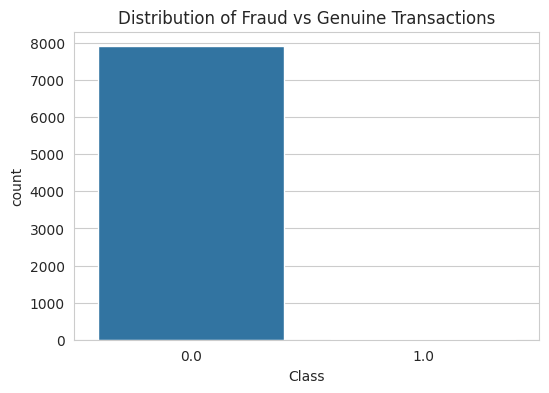

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Distribution of Fraud vs Genuine Transactions")

plt.show()

In [19]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True) * 100
)

print(fraud_percentage)

Class
0.0    99.684861
1.0     0.315139
Name: proportion, dtype: float64


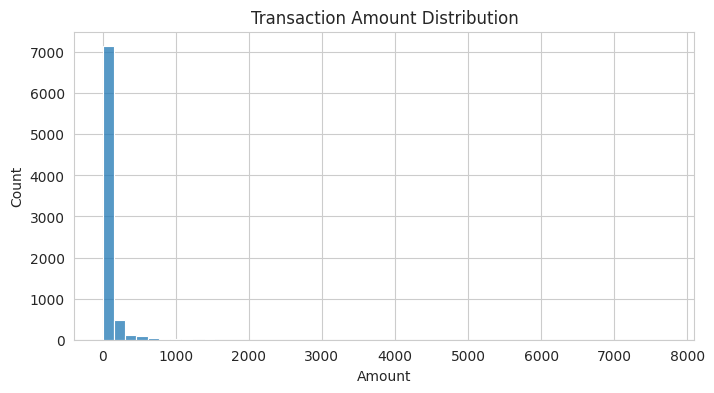

In [20]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

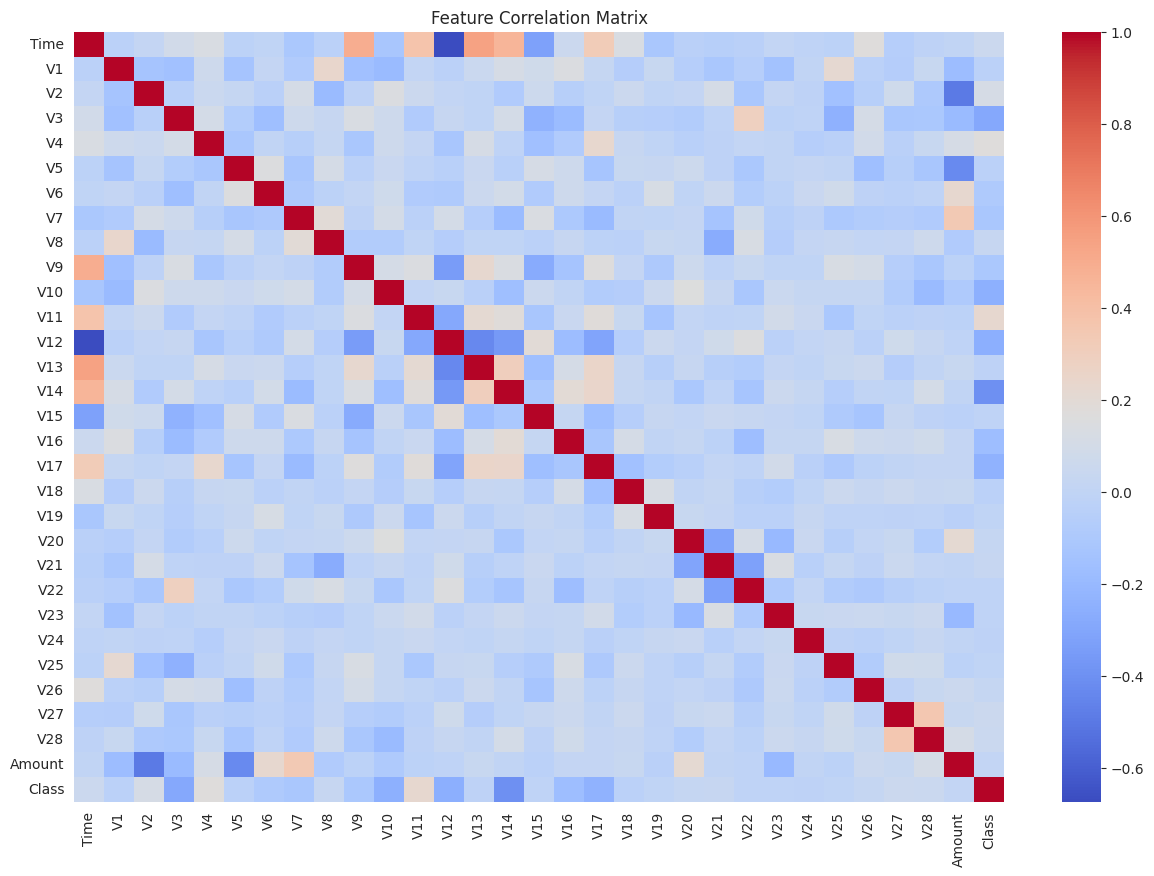

In [21]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [31]:
X = df.drop("Class", axis=1)

y = df["Class"]

print(X.shape)
print(y.shape)

(7933, 30)
(7933,)


In [29]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6346, 30)
(1587, 30)


In [36]:
scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(
    X_train[['Time', 'Amount']]
)

X_test[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

In [37]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
5808,0.627822,1.364227,-0.728132,0.636864,-0.789338,-0.861478,0.306739,-1.224053,0.081070,0.738266,...,0.136580,0.219848,0.736833,-0.268777,-0.860385,0.511923,-0.034915,-0.001044,0.001623,-0.148406
3029,-0.519194,-3.107205,-2.502244,2.943757,3.293462,3.104032,-1.056865,-2.163218,0.713575,-0.650697,...,0.891359,0.494520,0.632323,0.400372,0.119345,0.332722,0.321189,-0.002013,0.148593,-0.263270
2207,-0.786456,1.018059,-0.157090,0.410519,1.384888,-0.448033,-0.012430,-0.133831,0.244216,0.377094,...,-0.247766,-0.036974,-0.128012,-0.060383,0.181233,0.507739,-0.339624,0.011979,0.010651,-0.064524
1255,-1.022533,-1.391269,0.889885,1.990270,1.218071,1.017606,0.028331,0.530680,0.192361,-1.422533,...,-0.254071,-0.073482,-0.457138,-0.072360,-0.030036,-0.137286,-0.436751,-0.230497,0.204151,-0.315604
3828,-0.279998,-0.749016,1.129086,0.533418,0.872295,2.635754,-0.602326,-1.338940,-0.685009,-0.610479,...,-0.086052,0.632140,-0.980442,-3.109411,-1.281697,-0.279016,0.714328,0.233899,0.175285,-0.364993


In [38]:
from imblearn.over_sampling import SMOTE

In [39]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before:", y_train.value_counts())

print("After:", y_train_smote.value_counts())

Before: Class
0.0    6326
1.0      20
Name: count, dtype: int64
After: Class
0.0    6326
1.0    6326
Name: count, dtype: int64


In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [44]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1582
         1.0       1.00      1.00      1.00         5

    accuracy                           1.00      1587
   macro avg       1.00      1.00      1.00      1587
weighted avg       1.00      1.00      1.00      1587



In [45]:
print("Accuracy :", accuracy_score(y_test,y_pred_lr))

print("Precision:", precision_score(y_test,y_pred_lr))

print("Recall   :", recall_score(y_test,y_pred_lr))

print("F1 Score :", f1_score(y_test,y_pred_lr))

print("ROC AUC  :", roc_auc_score(
    y_test,
    y_prob_lr
))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


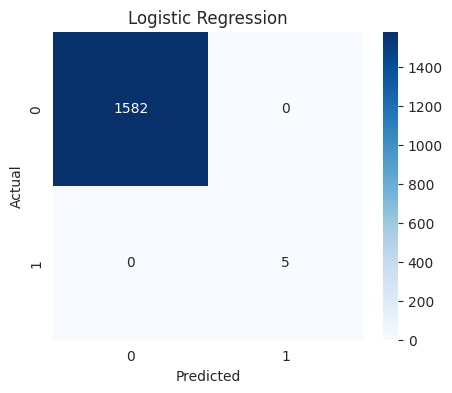

In [46]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [50]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [51]:
!pip install xgboost

In [52]:
from xgboost import XGBClassifier

In [53]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [54]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [55]:
def evaluate_model(name, y_true, y_pred, y_prob):

    return {

        "Model": name,

        "Accuracy": accuracy_score(y_true,y_pred),

        "Precision": precision_score(y_true,y_pred),

        "Recall": recall_score(y_true,y_pred),

        "F1": f1_score(y_true,y_pred),

        "ROC AUC": roc_auc_score(y_true,y_prob)

    }

In [56]:
results = pd.DataFrame([

    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    ),

    evaluate_model(
        "XGBoost",
        y_test,
        y_pred_xgb,
        y_prob_xgb
    )

])

results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,1.00000,1.000000,1.0,1.000000,1.0
1,Random Forest,0.99937,1.000000,0.8,0.888889,1.0
2,XGBoost,0.99937,0.833333,1.0,0.909091,1.0


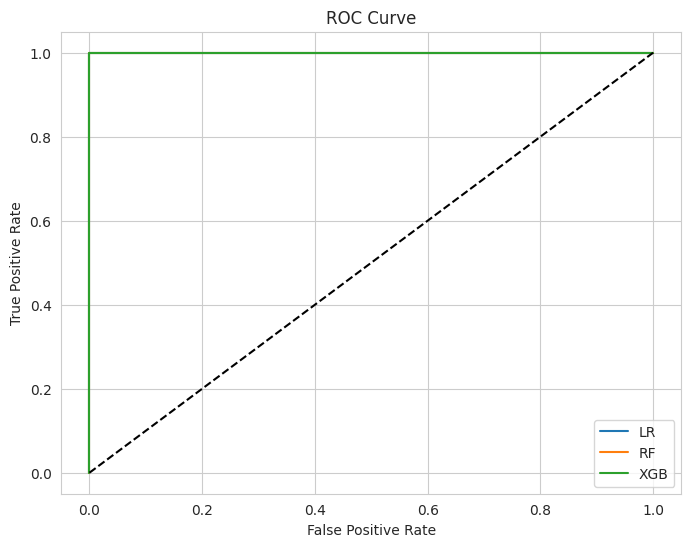

In [57]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name,prob in [

    ("LR",y_prob_lr),

    ("RF",y_prob_rf),

    ("XGB",y_prob_xgb)

]:

    fpr,tpr,_ = roc_curve(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

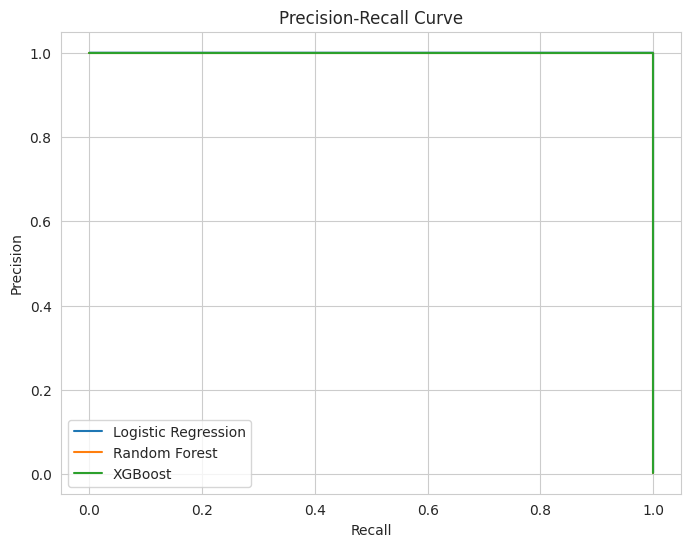

In [58]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, prob in [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest", y_prob_rf),
    ("XGBoost", y_prob_xgb)
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

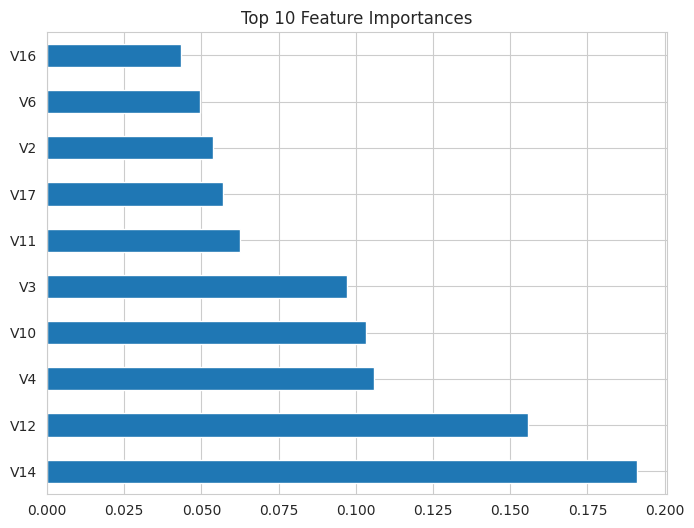

In [59]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance.nlargest(10).plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Top 10 Feature Importances")
plt.show()

In [60]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print(scores)

print(scores.mean())

[1.         0.89804046 1.         1.         1.        ]
0.9796080910240204


In [61]:
from sklearn.model_selection import RandomizedSearchCV

In [62]:
param_grid = {

    "n_estimators":[100,200,300,500],

    "max_depth":[5,10,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "bootstrap":[True,False]

}

In [63]:
search = RandomizedSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_distributions=param_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [64]:
search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1', verbose=2)

In [65]:
best_rf = search.best_estimator_

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}


In [66]:
y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:,1]

In [67]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1582
         1.0       1.00      0.80      0.89         5

    accuracy                           1.00      1587
   macro avg       1.00      0.90      0.94      1587
weighted avg       1.00      1.00      1.00      1587



In [68]:
print("ROC:",roc_auc_score(y_test,y_prob))

ROC: 1.0


In [69]:
from sklearn.pipeline import Pipeline

In [70]:
pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("classifier", best_rf)

])

In [71]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(max_depth=10, min_samples_split=10,
                                        n_estimators=200, random_state=42))])

In [72]:
import joblib

joblib.dump(
    pipeline,
    "fraud_pipeline.pkl"
)

['fraud_pipeline.pkl']

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Time", "Amount"])
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", best_rf)
])

pipeline.fit(X_train, y_train)

import joblib
joblib.dump(pipeline, "fraud_pipeline.pkl")

['fraud_pipeline.pkl']

In [74]:
loaded = joblib.load(
    "fraud_pipeline.pkl"
)

prediction = loaded.predict(
    X_test.iloc[[0]]
)

print(prediction)

[0.]
